## 📃Zadatak - Analiza ocena u online prodavnici
**Autor**: Uroš Đorđić

## 🏹Cilj zadatka:
U ovom zadatku cilj nam je da **analiziramo ocene proizvoda i rezultate prikazati pomoću odgovarajućeg grafika**. Hajde da vidimo kako ćemo to izvesti korak po korak!


## 👆 Prvi korak - Import
Osnovni i najbitniji korak je importovati Python biblioteke **matplotlib, seaborn i pandas**, a isto tako importovati podatke iz priloženog skupa podataka, jer preko njih vrštimo analize i vizualizacije:


In [107]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("online_store_data.csv")

## ✌️Drugi korak - Provera
Izvršićemo pregled podataka kako bismo odmah znali da li su tipovi podataka dobri i da li ih treba konvertovati:

In [108]:
print(df.dtypes)

product_name          object
category              object
price                float64
quantity_in_stock    float64
quantity_sold        float64
brand                 object
rating               float64
num_of_ratings       float64
date_added            object
color                 object
revenue              float64
dtype: object


## 👌Treci korak - Konvertovanje datuma
Vidimo iz prethodnog ispisa da nam je kolona **"date_added" tip 'object'** i to nam može stvarati problema kasnije kad budemo radili sa datumima. Sada ćemo tu kolonu da pretvorimo u **tip datuma**:

In [109]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print(df.dtypes)
print()

product_name                 object
category                     object
price                       float64
quantity_in_stock           float64
quantity_sold               float64
brand                        object
rating                      float64
num_of_ratings              float64
date_added           datetime64[ns]
color                        object
revenue                     float64
dtype: object



## 👊Četvrti korak - Tekstualna analiza
Sada možemo krenuti sa analizama! Prvo moramo naći **najvišu, pa tako i najnižu ocenu koju je neki proizvod dobio**. Ovde nećemo koristiti grafik, prikazaćemo rezultat običnim ispisom, a to ćemo uraditi pomoću **'min'** i **'max'** funkcije:

In [110]:
najvisa_ocena = df['rating'].max()
najniza_ocena = df['rating'].min()
print(f"Najviša ocena koju je neki proizvod dobio je {najvisa_ocena}")
print(f"Najniža ocena koju je neki proizvod dobio je {najniza_ocena}")

Najviša ocena koju je neki proizvod dobio je 9.75
Najniža ocena koju je neki proizvod dobio je 5.5


## 🖐️Peti korak - Analiza pomoću linijskog grafika
Sledeće što je potrebno da uradimo je analizarati kako se prosečna ocena menja kroz godine. To ćemo uraditi preko datuma kada je proizvod dodat u asortiman i rezultat ćemo prikazati **linijskim grafikom** (prikaz promene kroz vreme). 
- Izdvojićemo godinu iz datuma pomoću **".dt.year"** komande.
- Grupisaćemo podatke po vremenu kada su dodati u asortiman i odredićemo prosečnu ocenu.
- **reset_index()** je potreban jer groupby() vraća Series sa godinama kao indeksom, a Seaborn traži eksplicitne kolone za x i y, ne indekse.

Preko matplotlib-a i seaborn-a prikazaćemo linijski grafik
- *plt.figure* nam omogućava promenu veličine grafika
- *sns.lineplot* uzima podatke kao kriterijum šta će biti na grafiku
- *plt.title*, *plt.xlabel* i *plt.ylabel* ispisuju naslov i nazive osa


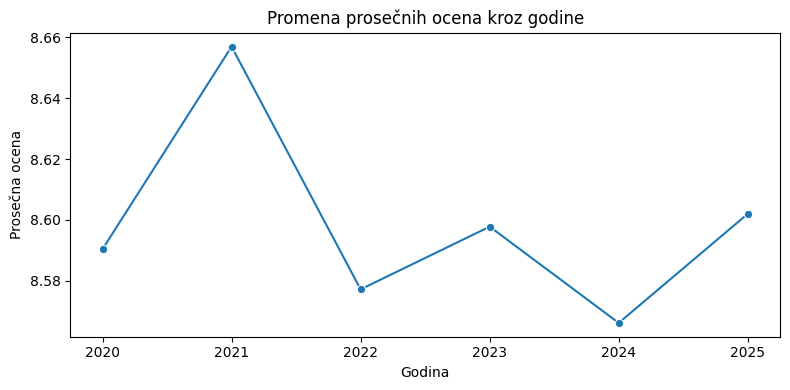

In [111]:
df['year'] = df['date_added'].dt.year
df_grouped = df.groupby("year")["rating"].mean().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=df_grouped, x="year", y="rating", marker='o')
plt.title("Promena prosečnih ocena kroz godine")
plt.xlabel("Godina")
plt.ylabel("Prosečna ocena")
plt.tight_layout()
plt.show()

## 🖐️👆 Šesti korak - Analiza pomoću stubičastog grafika
Analiziraćemo još i prosečne ocene po kategorijama proizvoda. Postupak analiziranja sa stubičastim grafikom se ne razlikuje mnogo od linijskog.
Novine i različitosti:
- umesto *sns.lineplot* koristimo stavili ***sns.barplot*** (stubičasti grafik)
- u *sns.barplot-u* smo takođe iskoristili " hue='category' " - različita boja za svaki stub (bolja preglednost)
- plt.xticks(rotation=45) - rotirali smo nazive kategorija kako se ne bi preklopili

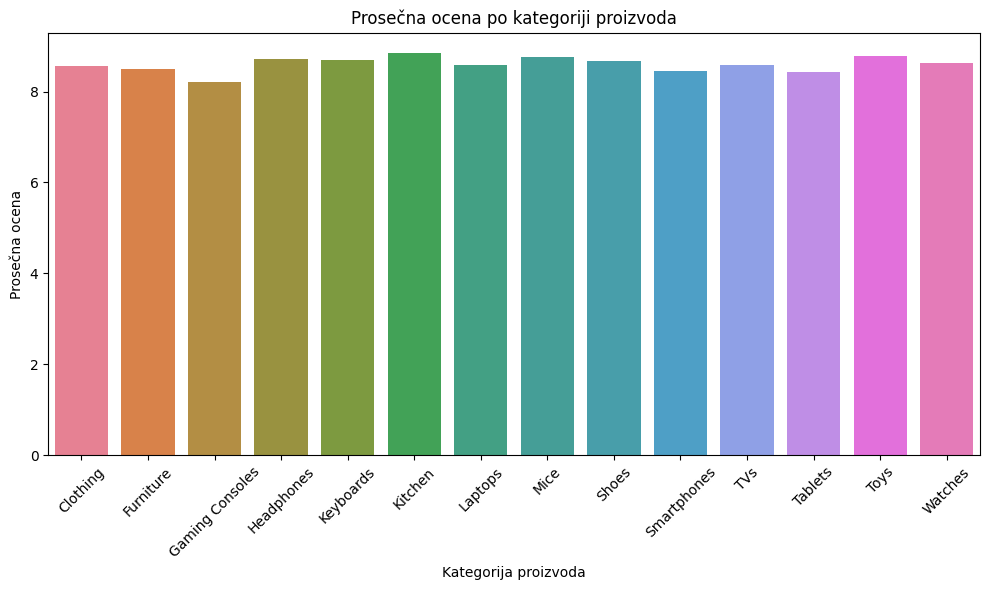

In [112]:
df_grouped = df.groupby("category")["rating"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=df_grouped, x="category", y="rating", hue="category")
plt.title("Prosečna ocena po kategoriji proizvoda")
plt.xlabel("Kategorija proizvoda")
plt.ylabel("Prosečna ocena")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🔒Zaključak
Pomoću svih ovih analiza koje su vrlo slične jedna drugoj zaključujemo jednu stvar - **prosečne ocene su vrlo slične**.
- Ocena proizvoda ne zavisi od godine proizvodnje, niti od kategorije proizvoda.
- Raspon prosečnih ocena je 0.5 (od 8.2 do 8.7), ali postoje izuzeci koje smo videli kod najveće i najmanje ocene.

Sve ovo nam govori da je stabilnost ocena odlična.

## 🤔 Refleksija
U ovom zadatku vidim da su grafici mnogo lakši i pregledniji od običnih tekstualnih ispisa kada imamo više podataka za analizu. 
- Možemo odmah uočiti najveće i najmanje vrednosti
- Lako vidimo uspone i padove vrednosti
- Boje su lepše od reči 

Matplotlib i Seaborn smo radili u nekim od prethodnih lekcija i to nije novina, u zadacima poput ovog ja više vežbam izradu Markdown-a i skoncentrišem se više na objašnjavanje mojih postupuka, nego rezultat. 

Tokom rada gledam:
- da su postupci jasni i kratki
- da sve izgleda uredno i pregledno
- da je lako shvatljivo i ljudima koji se ne razumeju

Sve u svemu, rad preko Jupyter-a se ne razlikuje od običnog programiranja, samo što se umesto korišćenja bezbroj znakova "#" može sve prikazati na lep i pregledan način.